In [ ]:
""" element to cartesian coordinates conversion and plotting of Hill sphere in AU """

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_hill_sphere_au():
    # --- 定数設定 (無次元化) ---
    # 距離の基準: 1.0 = 1 AU (太陽-地球間距離)
    a_AU = 1.0

    # 質量の基準
    M_sun = 1.989e30    # 太陽質量 (kg)
    M_earth = 5.972e24  # 地球質量 (kg)

    # ヒル球の半径計算 (単位: AU)
    # 公式: r = a * (m / 3M)^(1/3)
    r_hill_au = a_AU * (M_earth / (3 * M_sun))**(1/3)

    print(f"ヒル球の半径: {r_hill_au:.5f} AU")

    # --- 参考データ: 月の軌道 ---
    # 月までの距離: 約384,400 km
    # 1 AU: 約149,600,000 km
    km_per_au = 1.496e8
    r_moon_au = 384400 / km_per_au

    # --- プロット作成 ---
    fig, ax = plt.subplots(figsize=(8, 8))

    # 1. ヒル球 (Hill Sphere)
    hill_circle = patches.Circle((0, 0), r_hill_au,
                                 color='green', alpha=0.1,
                                 label='ヒル球 (Hill Sphere)')
    ax.add_patch(hill_circle)
    ax.add_patch(patches.Circle((0, 0), r_hill_au, color='green', fill=False, linestyle='--'))

    # 2. 月の軌道 (Moon Orbit)
    moon_circle = patches.Circle((0, 0), r_moon_au,
                                 edgecolor='gray', linestyle=':', fill=False,
                                 label='月の軌道 (Moon Orbit)')
    ax.add_patch(moon_circle)

    # 3. 地球 (Earth)
    ax.plot(0, 0, marker='o', color='blue', markersize=8, label='地球 (Earth)')

    # 4. ラグランジュ点 L1, L2 (近似)
    ax.scatter([-r_hill_au, r_hill_au], [0, 0], color='red', marker='x', label='L1 / L2 (近似)')

    # 5. 太陽方向の矢印
    ax.annotate('太陽の方向 (-1.0 AU)', xy=(-r_hill_au, 0), xytext=(-r_hill_au*1.4, 0),
                arrowprops=dict(facecolor='orange', arrowstyle='->', color='orange'),
                ha='right', va='center', color='darkorange', weight='bold')

    # --- グラフの装飾 ---
    limit = r_hill_au * 1.5
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_aspect('equal')

    ax.set_xlabel('地球からの距離 (AU)')
    ax.set_ylabel('地球からの距離 (AU)')
    ax.set_title(f'地球のヒル球 (無次元化距離)\n半径 $r_{{Hill}} \\approx {r_hill_au:.5f}$ AU', fontsize=14)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_hill_sphere_au()


In [ ]:
""" ゼロ速度曲線 (ZVC) と運動不可能領域のプロット（天体2周辺のズーム付き）"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle


def effective_potential(x, y, mu):
    """
    制限三体問題の有効ポテンシャル
    mu: 質量比パラメータ（小さい天体の質量 / 全質量）
    """
    # 二つの主天体の位置
    r1 = np.sqrt((x + mu) ** 2 + y**2)
    r2 = np.sqrt((x - 1 + mu) ** 2 + y**2)

    # ゼロ除算を避ける
    r1 = np.maximum(r1, 1e-10)
    r2 = np.maximum(r2, 1e-10)

    # 有効ポテンシャル
    U = 0.5 * (x**2 + y**2) + (1 - mu) / r1 + mu / r2

    return U


def plot_zero_velocity_curves(mu=0.01, jacobi_constants=None):
    """
    ゼロ速度曲線を描画（天体2周辺のズーム付き）
    mu: 質量比（例: 地球-月系なら約0.012）
    jacobi_constants: ヤコビ定数のリスト
    """
    # グリッドの作成（全体図用）
    x = np.linspace(-1.5, 1.5, 500)
    y = np.linspace(-1.5, 1.5, 500)
    X, Y = np.meshgrid(x, y)

    # 有効ポテンシャルの計算
    U = effective_potential(X, Y, mu)

    # ズーム領域用のグリッド（天体2周辺）
    zoom_range = 0.01  # ズーム範囲
    x_zoom = np.linspace(1 - mu - zoom_range, 1 - mu + zoom_range, 300)
    y_zoom = np.linspace(-zoom_range, zoom_range, 300)
    X_zoom, Y_zoom = np.meshgrid(x_zoom, y_zoom)
    U_zoom = effective_potential(X_zoom, Y_zoom, mu)

    # ヤコビ定数の設定（デフォルト値）
    if jacobi_constants is None:
        jacobi_constants = [3.0, 3.2, 3.4, 3.6, 3.8]

    # プロットの作成
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for idx, C in enumerate(jacobi_constants):
        if idx >= 6:
            break

        ax = axes[idx]

        # ゼロ速度曲線: 2U = C の等高線
        # 運動可能領域: 2U <= C (速度^2 = C - 2U >= 0)
        # 運動不可能領域: 2U > C

        forbidden_region = 2 * U > C
        forbidden_region_zoom = 2 * U_zoom > C

        # 運動不可能な領域を塗りつぶし（全体図）
        ax.contourf(
            X,
            Y,
            forbidden_region.astype(int),
            levels=[-0.5, 0.5],
            colors=["lightcoral"],
            alpha=0.6,
        )

        # ゼロ速度曲線を描画（全体図）
        contours = ax.contour(X, Y, 2 * U, levels=[C], colors="red", linewidths=2)

        # 二つの主天体の位置をプロット
        ax.plot(-mu, 0, "o", color="orange", markersize=10, label="Sun")
        ax.plot(1 - mu, 0, "o", color="skyblue", markersize=3, label="Earth")

        # # ラグランジュ点L1, L2, L3の概略位置（簡易計算）
        # L1_x = 1 - mu - (mu / 3) ** (1 / 3)
        # L2_x = 1 - mu + (mu / 3) ** (1 / 3)
        # L3_x = -mu - (1 - mu) * (7 * mu / 12)

        # ax.plot(
        #     [L1_x, L2_x, L3_x],
        #     [0, 0, 0],
        #     "x",
        #     color="orange",
        #     markersize=8,
        #     label="L1,L2,L3",
        # )

        # ズーム領域を示す矩形を描画
        from matplotlib.patches import Rectangle, FancyBboxPatch, ConnectionPatch

        zoom_rect = Rectangle(
            (1 - mu - zoom_range, -zoom_range),
            2 * zoom_range,
            2 * zoom_range,
            linewidth=2,
            edgecolor="darkblue",
            facecolor="none",
            linestyle="-",
        )
        ax.add_patch(zoom_rect)

        # インセット軸（ズーム図）を作成 - 軸の外側に配置
        from mpl_toolkits.axes_grid1.inset_locator import inset_axes

        ax_zoom = inset_axes(
            ax,
            width="50%",
            height="50%",
            bbox_to_anchor=(0.7, 0.5, 0.9, 0.9),
            bbox_transform=ax.transAxes,
            loc="center left",
            borderpad=0,
        )

        # ズーム図に背景色を設定
        ax_zoom.set_facecolor("#FFFFF0")

        # ズーム図に運動不可能領域を塗りつぶし
        ax_zoom.contourf(
            X_zoom,
            Y_zoom,
            forbidden_region_zoom.astype(int),
            levels=[-0.5, 0.5],
            colors=["lightcoral"],
            alpha=0.6,
        )

        # ズーム図にゼロ速度曲線を描画
        ax_zoom.contour(
            X_zoom, Y_zoom, 2 * U_zoom, levels=[C], colors="red", linewidths=2
        )

        # ズーム図に天体2とラグランジュ点を表示
        ax_zoom.plot(1 - mu, 0, "o", color="skyblue", markersize=3)

        ax_zoom.set_xlim(1 - mu - zoom_range, 1 - mu + zoom_range)
        ax_zoom.set_ylim(-zoom_range, zoom_range)
        ax_zoom.set_aspect("equal")
        ax_zoom.grid(True, alpha=0.3, linewidth=0.5)
        ax_zoom.tick_params(labelsize=8)

        # ズーム図の枠を強調
        for spine in ax_zoom.spines.values():
            spine.set_edgecolor("darkblue")
            spine.set_linewidth(2.5)

        # 元の領域とズーム図を線で繋ぐ
        # 右下の角を左下に繋ぐ
        con1 = ConnectionPatch(
            (1 - mu - zoom_range, -zoom_range),
            (0, 0),
            "data",
            "axes fraction",
            axesA=ax,
            axesB=ax_zoom,
            color="darkblue",
            linewidth=1.5,
            linestyle="-",
            alpha=0.7,
        )
        ax.add_artist(con1)

        # 右上の角を左上に繋ぐ
        con2 = ConnectionPatch(
            (1 - mu + zoom_range, -zoom_range),
            (1, 0),
            "data",
            "axes fraction",
            axesA=ax,
            axesB=ax_zoom,
            color="darkblue",
            linewidth=1.5,
            linestyle="-",
            alpha=0.7,
        )
        ax.add_artist(con2)

        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_title(f"C_j = {C:.6f}")
        ax.set_aspect("equal")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    # 最後のサブプロットを非表示
    if len(jacobi_constants) < 6:
        axes[5].axis("off")

    plt.suptitle(
        f"ZVC and forbidden regions \n" + f"μ = {mu:e}",
        fontsize=14,
        y=0.98,
    )

    plt.tight_layout()
    plt.show()


# 実行例
print()

# 地球-月系の質量比
mu_earth_moon = 0.01215
gm_sun = 1.32712440041279419e20  # // heliocentric gravitational parameter (m3 s-2)
gm_earth = 3.98600435507e14  # // geocentric gravitational parameter (m3 s-2)
mu_sun_earth = gm_earth / (gm_sun + gm_earth)
# 様々なヤコビ定数でプロット
# jacobi_values = [0.00089, 4, 5, 8, 10, 12]
jacobi_values = [3.0011292385, 3.00118437218498]
plot_zero_velocity_curves(mu=mu_sun_earth, jacobi_constants=jacobi_values)


In [ ]:
""" ゼロ速度曲線 (ZVC) のプロット """

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


def potential(x, y, mu):
    r1 = np.sqrt((x + mu) ** 2 + y**2)
    r2 = np.sqrt((x - 1 + mu) ** 2 + y**2)
    return x**2 + y**2 + 2 * (1 - mu) / r1 + 2 * mu / r2


def zero_velocity_curves(mu, C_values):
    x = np.linspace(-2.0, 2.0, 1000)
    y = np.linspace(-2.0, 2.0, 1000)
    # x = np.linspace(0.97, 1.03, 500)
    # y = np.linspace(-0.03, 0.03, 500)
    X, Y = np.meshgrid(x, y)

    Z = potential(X, Y, mu)

    plt.figure(figsize=(12, 10))
    colors = ["#0000FF", "#00FFFF", "#00FF00", "#FFFF00", "#FF0000"]
    n_bins = 100
    cmap = LinearSegmentedColormap.from_list("custom", colors, N=n_bins)

    contour = plt.contourf(X, Y, Z, levels=C_values, cmap=cmap)
    plt.colorbar(contour, label="Jacobi Integral")

    # plt.plot([0.97, 1.03], [0, 0], "k--")
    plt.title(f"Zero Velocity Curves (μ = {mu})")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis("equal")
    plt.grid(True)
    plt.show()


# パラメータの設定
gm_sun = 1.32712440041279419e20  # // heliocentric gravitational parameter (m3 s-2)
gm_earth = 3.98600435507e14  # // geocentric gravitational parameter (m3 s-2)
mu = gm_earth / (gm_sun + gm_earth)
C_values = np.linspace(3.000, 4.001, 1000)  # ヤコビ積分の値の配列
zero_velocity_curves(mu, C_values)


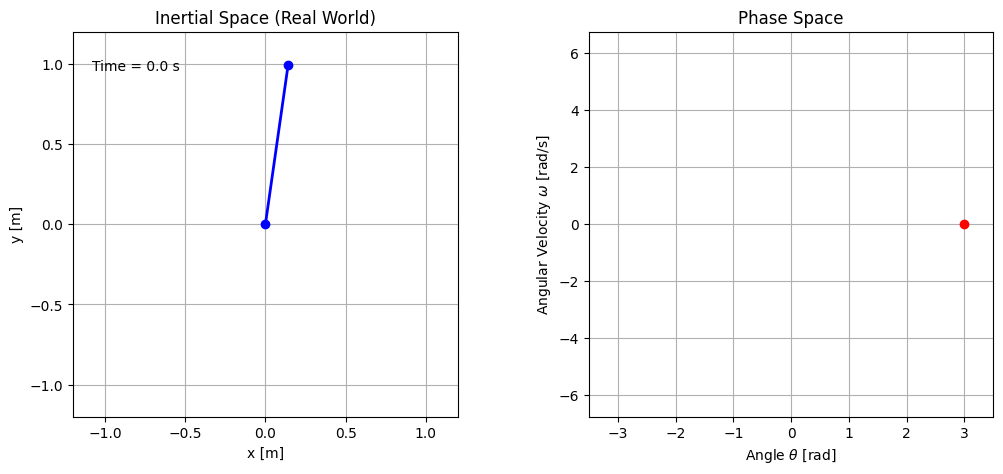

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.integrate import odeint

# --- パラメータ設定 ---
g = 9.81       # 重力加速度 [m/s^2]
L = 1.0        # 振り子の長さ [m]
m = 1.0        # おもりの質量 [kg] (運動方程式には影響しませんが概念として)
t_max = 20.0   # シミュレーション時間 [s]
dt = 0.05      # 時間刻み [s]

# 初期状態 [theta(ラジアン), omega(ラジアン/秒)]
# ※ ほぼ真上(3.14)に近い値にすると、ゆっくり動き出し、位相空間で「目」のような形が見えます
init_state = [3.0, 0.0] 

# --- 運動方程式の定義 ---
def pendulum_derivs(state, t, g, L):
    theta, omega = state
    dydt = [omega, -(g/L) * np.sin(theta)]
    return dydt

# --- 時間発展の計算 (ODEを解く) ---
t = np.arange(0, t_max, dt)
y = odeint(pendulum_derivs, init_state, t, args=(g, L))

theta = y[:, 0]
omega = y[:, 1]

# 直交座標系への変換（実空間プロット用）
x = L * np.sin(theta)
y_pos = -L * np.cos(theta)

# --- アニメーションの準備 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plt.subplots_adjust(wspace=0.3)

# 1. 実空間（左側）の設定
ax1.set_title('Inertial Space (Real World)')
ax1.set_xlabel('x [m]')
ax1.set_ylabel('y [m]')
ax1.set_xlim(-L*1.2, L*1.2)
ax1.set_ylim(-L*1.2, L*1.2)
ax1.set_aspect('equal')
ax1.grid()

# 振り子のロッドとおもり
line, = ax1.plot([], [], 'o-', lw=2, color='blue')
time_text = ax1.text(0.05, 0.9, '', transform=ax1.transAxes)

# 2. 位相空間（右側）の設定
ax2.set_title('Phase Space')
ax2.set_xlabel(r'Angle $\theta$ [rad]')
ax2.set_ylabel(r'Angular Velocity $\omega$ [rad/s]')
ax2.set_xlim(np.min(theta)-0.5, np.max(theta)+0.5)
ax2.set_ylim(np.min(omega)-0.5, np.max(omega)+0.5)
ax2.grid()

# 軌跡と現在の点
traj, = ax2.plot([], [], '-', lw=1, color='green', alpha=0.5) # 軌跡
point, = ax2.plot([], [], 'o', color='red') # 現在の状態

# --- アニメーション更新関数 ---
def update(i):
    # 実空間の更新
    thisx = [0, x[i]]
    thisy = [0, y_pos[i]]
    line.set_data(thisx, thisy)
    time_text.set_text(f'Time = {t[i]:.1f} s')

    # 位相空間の更新
    # 過去の軌跡を表示
    traj.set_data(theta[:i+1], omega[:i+1])
    # 現在の点を表示
    point.set_data([theta[i]], [omega[i]])

    return line, time_text, traj, point

# アニメーションの作成
ani = animation.FuncAnimation(
    fig, update, frames=len(t), interval=dt*1000, blit=True
)

plt.show()